<a href="https://colab.research.google.com/github/MamoMGD1/ISE302-DataMining-GroupProject/blob/main/students/models/model_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 4 — Fast Car Classifier (Naive Bayes)

## Research Question
Based on a car's body type, fuel type, drivetrain, and transmission — can we predict whether it is a fast car (0–100 km/h under 11.5 seconds)?

## Introduction
This notebook applies **Gaussian Naive Bayes** to classify cars as "fast" or "slow" based on categorical and encoded features.

**Rules for this notebook:**
- Uses **unscaled data** (`proceed_dataset_without_scaling.csv`)
- You **must use `GaussianNB`** — no other algorithm is acceptable
- You **must create the `hızlı_araba` binary column** before training (see Feature Engineering)
- **Note:** Naive Bayes assumes feature independence — this is an approximation that should be acknowledged in your analysis
- You **may choose different features**, add features, and tune hyperparameters — but you **cannot change the general technique category** (must remain Naive Bayes)

## Data Import
Loads all required libraries and reads the unscaled dataset directly from GitHub. The dataset is printed with its shape so you can verify it loaded correctly.

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2589, 87)


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,...,Hızlanma (0-100),Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat
0,2425000,2025,6001,0.507585,9.730597,9.436162,2024.524726,3,5,6.255935,...,10.1,198.0,8.388223,1806.0,1590.0,7.530480,1315.0,7.881182,17,14.701342
1,2900000,2025,16000,0.540567,9.801196,9.426602,2024.561718,4,5,6.312241,...,9.2,199.0,8.395252,1848.0,1625.0,7.591862,1450.0,7.888335,19,14.880222
2,1150000,2015,265000,0.437396,9.847922,9.310729,2015.500000,4,5,5.996452,...,12.4,180.0,8.384804,1800.0,1590.0,7.555382,1365.0,7.881182,19,13.955273
3,1240000,2014,196000,0.403619,9.796904,9.310729,2015.500000,4,5,5.996452,...,10.7,182.0,8.384804,1800.0,1590.0,7.603898,1461.0,7.881182,17,14.030623
4,690000,2011,305000,0.354720,9.696057,9.341037,2011.476979,4,5,6.115519,...,12.2,174.0,8.370084,1780.0,1615.0,7.565793,1407.0,7.875119,16,13.444448


##Feature Engineering
Creates the binary target column `hızlı_araba` based on the `Hızlanma (0-100)` column:

1 = fast car (0–100 km/h in under 11.5 seconds)
0 = slow car (11.5 seconds or more)

The `Hızlanma (0-100)` column is not included in the feature set in the next step to avoid data leakage — the model would otherwise be directly predicting from the value it's trying to classify.

In [136]:
# Create binary target: 1 = fast car (0-100 km/h in under 9 seconds), 0 = slow car
# We drop 'Hızlanma (0-100)' from features after creating the target to avoid data leakage
df['hızlı_araba'] = (df['Hızlanma (0-100)'] < 11.5).astype(int)
print(f"Fast cars: {df['hızlı_araba'].sum()} ({df['hızlı_araba'].mean()*100:.1f}%)")
print(f"Slow cars: {(df['hızlı_araba'] == 0).sum()} ({(df['hızlı_araba'] == 0).mean()*100:.1f}%)")

Fast cars: 1292 (49.9%)
Slow cars: 1297 (50.1%)


##Feature Selection
Selects the features used for training. The recommended list includes weight, engine power, one-hot encoded body type and drivetrain columns, fuel type dummies, transmission type, and average fuel consumption. Any column from the list that doesn't exist in the loaded dataframe is automatically filtered out.
Missing values are filled with 0. The data is then split 80/20 into training and test sets, with stratification to preserve the class ratio in both splits.

Most of the selected features are the ones we suspect they may effect our model's performance, a lot of them will be removed

In [137]:
# recommended_features = [
#     'Yıl',
#     'Kilometre',
#     'İlan Tarihi',
#     'Ortalama Kasko',
#     'Ortalama Trafik Sigortası',
#     'Üretim Yılı (İlk/Son)',
#     'Silindir Sayısı',
#     'Koltuk Sayısı',
#     'Bagaj Hacmi',
#     'Yakıt Deposu',
#     'Seri',
#     'Model',
#     'Vites Tipi',
#     'Sınıfı',
#     'is_Nissan',
#     'Yakıt Tipi_Dizel',
#     'Yakıt Tipi_Elektrik',
#     'Yakıt Tipi_Hibrit',
#     'Yakıt Tipi_LPG & Benzin',
#     'Kasa Tipi_Coupe',
#     'Kasa Tipi_Crossover',
#     'Kasa Tipi_Hard top',
#     'Kasa Tipi_Panelvan',
#     'Kasa Tipi_Pick-Up',
#     'Kasa Tipi_SUV',
#     'Çekiş_AWD (Elektronik)',
#     'Çekiş_Arkadan İtiş',
#     'Çekiş_Önden Çekiş',
#     'total_changed_parts',
#     'is_fully_original',
#     'Motor Hacmi',
#     'Motor Gücü',
#     'Ort. Yakıt Tüketimi',
#     'Tork',
#     'Maksimum Güç',
#     'Minimum Güç',
#     'Maksimum Hız',
#     'Uzunluk',
#     'Genişlik',
#     'Yükseklik',
#     'Ağırlık',
#     'Boş Ağırlığı',
#     'Aks Aralığı',
#     'Jant Boyutu',
# ]
# features = [f for f in recommended_features if f in df.columns]
# target = 'hızlı_araba'

# X = df[features].fillna(0)
# y = df[target]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
# print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
# print(f"Class balance in train: {y_train.value_counts().to_dict()}")

##Using SKlearn feature_selection to find out which features can help us the most.
Important Note: After executing the cell below only take the top features needed, maybe like 4-6 features to not over train the model
you can test out different n_features_to_select and see if less or more features lead to better accuracy



In [138]:
# from sklearn.feature_selection import SequentialFeatureSelector
# from sklearn.naive_bayes import GaussianNB

# # 1. Initialize the model
# gnb = GaussianNB()

# # 2. Initialize the Selector
# # 'n_features_to_select' can be an integer or "auto"
# # 'direction' can be 'forward' or 'backward'
# sfs = SequentialFeatureSelector(
#     gnb,
#     n_features_to_select=10,  # Let's find the top 10 best features
#     direction='forward',
#     scoring='accuracy',
#     cv=5,
#     n_jobs=-1 # Uses all your CPU cores to speed it up
# )

# print("Starting feature selection... (this may take a minute)")
# sfs.fit(X_train, y_train)

# # 3. Get the names of the features that were chosen
# best_features = X_train.columns[sfs.get_support()].tolist()

# print("-" * 30)
# print(f"Best 10 features identified:")
# for i, feat in enumerate(best_features, 1):
#     print(f"{i}. {feat}")

# # 4. Evaluate the model with ONLY those features
# X_train_best = sfs.transform(X_train)
# X_test_best = sfs.transform(X_test)

# gnb.fit(X_train_best, y_train)
# final_accuracy = gnb.score(X_test_best, y_test)

# print("-" * 30)
# print(f"Final Accuracy with top features: {final_accuracy:.4f}")



##the most accurate model for us contais 4 features which are:
1. Ortalama Trafik Sigortası
2. Motor Hacmi
3. Motor Gücü
4. Genişlik

After reaching that conclusion we redo the feature selection with only 4


In [139]:
recommended_features = [
    'Ortalama Trafik Sigortası',
    'Motor Hacmi',
    'Motor Gücü',
    'Genişlik',
]
features = [f for f in recommended_features if f in df.columns]
target = 'hızlı_araba'

X = df[features].fillna(0)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Class balance in train: {y_train.value_counts().to_dict()}")

Training set: (2071, 4), Test set: (518, 4)
Class balance in train: {0: 1037, 1: 1034}


##Model Training
Trains a `GaussianNB` classifier with `var_smoothing=1e-9`. This smoothing parameter controls how much variance is added to each feature's distribution to stabilize likelihood estimates — higher values make the model less sensitive to rare feature values.
After fitting, the model generates both hard predictions `(y_pred)` and probability scores `(y_prob)` on the test set. The probability scores reflect the model's confidence that each car is a fast car.

In [140]:
from sklearn.naive_bayes import GaussianNB

# GaussianNB has minimal hyperparameters you may experiment with var_smoothing
model = GaussianNB(var_smoothing=1e-9)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of being a fast car
print("Naive Bayes model trained.")

Naive Bayes model trained.


##Evaluation
###Classification Report
Prints `precision`, `recall`, `F1-score`, and `support` for both classes `(Slow / Fast)` using the actual test set predictions from your trained model.

In [141]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Slow (0)', 'Fast (1)']))

=== Classification Report ===
              precision    recall  f1-score   support

    Slow (0)       0.89      0.81      0.85       260
    Fast (1)       0.82      0.90      0.86       258

    accuracy                           0.85       518
   macro avg       0.86      0.85      0.85       518
weighted avg       0.86      0.85      0.85       518



##Confusion Matrix
Visualizes prediction outcomes as a heatmap. Each cell shows the count of predictions in that true-label / predicted-label combination. Correct predictions fall on the diagonal; off-diagonal cells represent misclassifications.

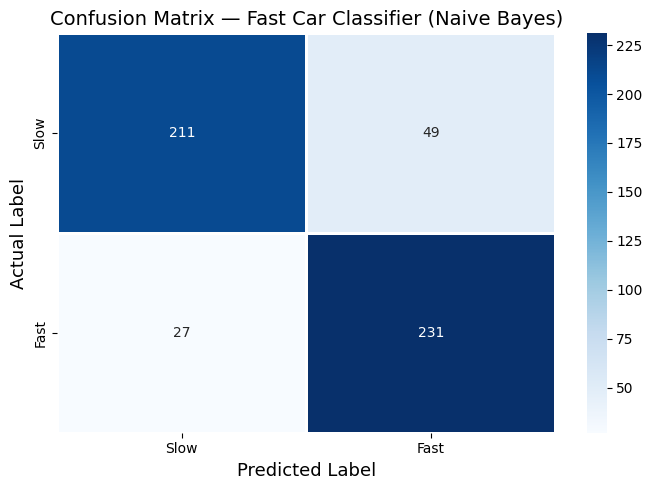

In [142]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Slow', 'Fast'], yticklabels=['Slow', 'Fast'],
            linewidths=1, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('Actual Label', fontsize=13)
ax.set_title('Confusion Matrix — Fast Car Classifier (Naive Bayes)', fontsize=14)
plt.tight_layout()
plt.show()